# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is "linear" based on the prediction as a linear function or combination of the parameters such as predictors and their coefficients. It is linear in the coefficients.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

We drop one column so the model doesn't break from perfect collinearity. The dropped category becomes the baseline, and the intercept represents it. The other dummy coefficients show how each group differs from that baseline.

3. Can linear regression be used for classification? Explain why, or why not.

Linear regression is made for continuous data, not categories. When used for classification, it gives number predictions that have to be turned into classes, and those numbers can be outside 0–1. So it usually isn’t a good choice for classification compared to models designed for it.


4. What are signs that your linear model is over-fitting?

It is often that a linear model is associated with multicollinearity when overfitting. Additionally, coefficients become poorly determined.

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Part 1:
Predict y using the other predictors and keep what's left over (the residuals). Then, predict the variable you care about using the other predictors and keep what's left over. These leftovers represent the parts that aren't explained by the other variables.

Part 2:
Reviewing how those leftovers relate to one another, regress the leftover part of y on the leftover part of that variable. This result gives the variables true independent effect.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

Nonlinear relationships can be incorporated by adding additional variables that capture the pattern, such as transformed or derived versions of the predictors. Linear regression can then combine these variables using weights to build a more complex model.

7. What is the interpretation of the slope coefficient in a linear regression?

The slope coefficient b(k) represents the expected change in the predicted outcome y(^) when x(k) increases by one unit, holding the other variables constant.

8. Compare the train/test split and $k$-fold cross validation.

A train/test split evaluates the model by fitting it on one part of the data and measuring performance on separate test or validation data. This helps detect overfitting, since a model can fit the training data well but perform poorly on new data. Cross validation extends this idea by repeating the process across multiple splits to obtain a more reliable estimate of model performance.

9. How is the $k$ in $k$-fold cross validation typically selected?

The value of k is chosen to balance accuracy and reliability with computational effort. Larger values use more data for training and produce more stable estimates of performance, but require more repeated model fitting. In practice, moderate values are typically used.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()


Download complete
Extracting data files...
Data extracted


In [9]:
import pandas as pd

df = pd.read_csv("Q1_clean.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Q1_clean.csv'

In [10]:
df = df.rename(columns={
    "Price per night": "price",
    "Review Scores Rating": "review_score",
    "Neighbourhood": "neighbourhood"
})

NameError: name 'df' is not defined

In [ ]:
df = df[["Price", "review_score","Neighbourhood "]].dropna()

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
import numpy as np

In [ ]:
df["log_price"] = np.log(df["Price"])

In [ ]:
group_means = df.groupby("Neighbourhood")[["Price", "review_score"]].mean()
print(group_means)

                    Price  review_score
Neighbourhood                          
Bronx           75.276498     91.654378
Brooklyn       127.747378     92.363497
Manhattan      183.664286     91.801496
Queens          96.857233     91.549057
Staten Island  146.166667     90.843750


In [ ]:
print(group_means.sort_values("Price", ascending=False))

                    Price  review_score
Neighbourhood                          
Manhattan      183.664286     91.801496
Staten Island  146.166667     90.843750
Brooklyn       127.747378     92.363497
Queens          96.857233     91.549057
Bronx           75.276498     91.654378


The most expensive borough on average is Manhattan.

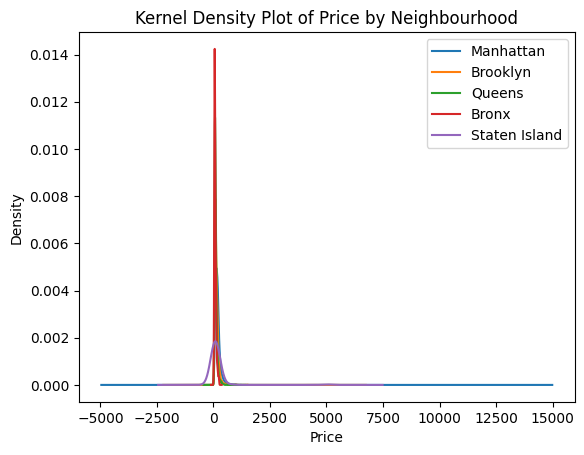

In [ ]:
for n in df["Neighbourhood"].unique():
    df.loc[df["Neighbourhood"] == n, "Price"].plot(kind="kde", label=n)

plt.title("Kernel Density Plot of Price by Neighbourhood")
plt.xlabel("Price")
plt.legend()
plt.show()

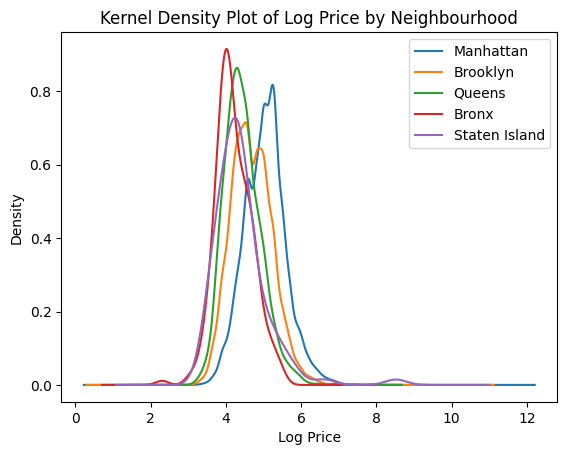

In [ ]:
for n in df["Neighbourhood"].unique():
    df.loc[df["Neighbourhood"] == n, "log_price"].plot(kind="kde", label=n)

plt.title("Kernel Density Plot of Log Price by Neighbourhood")
plt.xlabel("Log Price")
plt.legend()
plt.show()

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True)

X = dummies
y = df["Price"]

model_neigh = LinearRegression()
model_neigh.fit(X, y)

print("Intercept (reference group mean):", model_neigh.intercept_)

for name, coef in zip(X.columns, model_neigh.coef_):
    print(name, coef)

Intercept (reference group mean): 75.27649769585331
Brooklyn 52.470880647495
Manhattan 108.38778862566352
Queens 21.580735008549482
Staten Island 70.89016897081363


I regressed price on neighbourhood using one-hot encoding and dropped the first category to avoid the dummy variable trap. The omitted borough becomes the reference group, and the intercept represents its average price. Each coefficient shows how much more or less expensive the other boroughs are relative to that reference group. These coefficients correspond directly to the differences in group means from Part 1.

In [ ]:
X = df[["review_score"]]
y = df["Price"]

model_score = LinearRegression()
model_score.fit(X, y)

print("Intercept:", model_score.intercept_)
print("Slope (review_score):", model_score.coef_[0])

Intercept: 60.878390657123546
Slope (review_score): 1.0208266022674763


The slope coefficient indicates the expected change in price for a one-point increase in review score. For example, if the coefficient is positive, higher ratings are associated with higher prices.

Q2.4

In [ ]:
X = pd.concat([df[["review_score"]], dummies], axis=1)
y = df["Price"]

model_both = LinearRegression()
model_both.fit(X, y)

print("Intercept:", model_both.intercept_)

for name, coef in zip(X.columns, model_both.coef_):
    print(name, coef)

Intercept: -23.812561011673324
review_score 1.0811164834598561
Brooklyn 51.7042401559102
Manhattan 108.22873656676599
Queens 21.694599576536717
Staten Island 71.76655213403366


After adding neighbourhood controls, the coefficient on review score may change because part of the relationship between price and rating was due to differences across boroughs. The neighbourhood coefficients now represent differences in price holding review score constant rather than simple averages.

Q2.5

In [ ]:
X = pd.concat([df[["review_score"]], dummies], axis=1)

for col in dummies.columns:
    X[f"review_score_x_{col}"] = df["review_score"] * dummies[col]

y = df["Price"]

model_interact = LinearRegression()
model_interact.fit(X, y)

LinearRegression()

In [ ]:
print("Intercept:", model_interact.intercept_)

for name, coef in zip(X.columns, model_interact.coef_):
    print(name, coef)

Intercept: 22.63838492209186
review_score 0.5743109493639864
Brooklyn -16.392990175462927
Manhattan 41.315428948452976
Queens 28.259701286903276
Staten Island 2963.0710401207384
review_score_x_Brooklyn 0.7411652657447441
review_score_x_Manhattan 0.7297034445633539
review_score_x_Queens -0.07229434536634072
review_score_x_Staten Island -31.831747574076203


I included interaction terms so that review score could have a different effect on price in each borough. If the interaction coefficients are small, the slopes are similar across boroughs; if they are large, the relationship between rating and price differs by location.

Q2.6

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
rmse4 = np.sqrt(-cross_val_score(
    LinearRegression(), X.iloc[:, :1+len(dummies.columns)], y,
    cv=kf, scoring="neg_mean_squared_error"
).mean())

print("RMSE model 4:", rmse4)

RMSE model 4: 145.15557958920684


In [ ]:
rmse5 = np.sqrt(-cross_val_score(
    LinearRegression(), X, y,
    cv=kf, scoring="neg_mean_squared_error"
).mean())

print("RMSE model 5:", rmse5)

RMSE model 5: 146.04171816953033


I used k-fold cross validation to compare the models’ predictive performance. The model with the lower RMSE provides better out-of-sample predictions.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [10]:
df = pd.read_csv("./data/cars_hw.csv")
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [11]:
df["Price"].describe()

,Price
count,9.760000e+02
mean,7.410195e+05
std,3.673234e+05
min,1.880000e+05
25%,4.757500e+05
50%,6.665000e+05
75%,8.830000e+05
max,2.941000e+06


In [20]:
df["Price"].plot(kind="kde"). # make density plot of kernal graph
plt.title("Kernel Density Plot of Price")
plt.xlabel("Price")
plt.show()

SyntaxError: invalid syntax (1176825505.py, line 1)

In [12]:
df.groupby("Body_Type")["Price"].describe()

,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.050952e+05,72849.780207,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.339773e+05,173086.729837,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.264211e+05,184093.488526,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.097841e+05,286736.770092,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.176495e+06,417479.028217,559000.0,860000.0,1065000.0,1491250.0,2100000.0


Crossover is the most expensive car, and SUV has the highest variance.

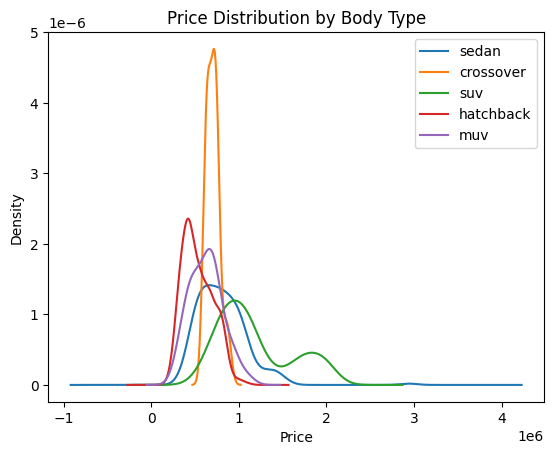

In [13]:
for b in df["Body_Type"].dropna().unique():
    df.loc[df["Body_Type"] == b, "Price"].dropna().plot(kind="kde", label=b)

plt.title("Price Distribution by Body Type")
plt.xlabel("Price")
plt.legend()
plt.show()

The most expensive car types are the ones with the highest mean prices in the grouped summary table. The car types with the most variance are the ones with the largest standard deviation, which also tend to show the widest spread in the grouped density plot.

In [14]:
from sklearn.linear_model import LinearRegression

X = df[["Seating_Capacity"]]
y = df["Price"]

model_seat = LinearRegression()
model_seat.fit(X, y)

print("Intercept:", model_seat.intercept_)
print("Slope:", model_seat.coef_[0])

Intercept: 439032.0141018266
Slope: 59267.99803672175


On average, a one-unit increase in seating capacity is associated with an increase of about 59267 rupees in price.

In [15]:
seat_dummies = pd.get_dummies(df["Seating_Capacity"], drop_first=True)
X_cat = seat_dummies
y = df["Price"]

model_seat_cat = LinearRegression()
model_seat_cat.fit(X_cat, y)

print("Intercept:", model_seat_cat.intercept_)

for name, coef in zip(X_cat.columns, model_seat_cat.coef_):
    print(name, coef)

Intercept: 188000.00000000314
5 546483.8709677386
6 1455999.9999999998
7 735948.7179487164
8 271799.999999999


In [16]:
df.groupby("Seating_Capacity")["Price"].mean().sort_index()

,Price
Seating_Capacity,
4,1.880000e+05
5,7.344839e+05
6,1.644000e+06
7,9.239487e+05
8,4.598000e+05


Using seating capacity as a number gives  a slope of 59,267, so each extra seat adds about 59,267 rupees to the price on average. When seats are treated as categories, each seat count has its own average price. The prices don't go up in an even/steady way. For example, 6 seat cars cost more than cars with 7 or 8 seats. Therefore, the relationship between seats and price is not linear.

Q3.3

In [21]:
df["Age"] = 2026 - df["Make_Year"]
df[["Make_Year", "Age"]].head()

,Make_Year,Age
0,2017,9
1,2016,10
2,2019,7
3,2017,9
4,2017,9


In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

kf = KFold(n_splits=10, shuffle=True, random_state=42)

results = []

for degree in range(1, 7):

    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(df[["Age"]])

    model = LinearRegression()

    mse_scores = cross_val_score(
        model, X_poly, df["Price"],
        cv=kf,
        scoring="neg_mean_squared_error"
    )

    rmse = np.sqrt(-mse_scores.mean())
    results.append((degree, rmse))

print(results)

[(1, np.float64(312053.2776049577)), (2, np.float64(312082.85112872685)), (3, np.float64(311035.6970163447)), (4, np.float64(310201.6090420433)), (5, np.float64(308650.3450729246)), (6, np.float64(308802.4585399601))]


In [24]:
best_degree = min(results, key=lambda x: x[1])[0]
print("Optimal number of powers of Age:", best_degree)

Optimal number of powers of Age: 5


In [25]:
X_best = pd.DataFrame()

for p in range(1, best_degree + 1):
    X_best[f"Age^{p}"] = df["Age"] ** p

final_model = LinearRegression()
final_model.fit(X_best, df["Price"])

df["predicted_price"] = final_model.predict(X_best)

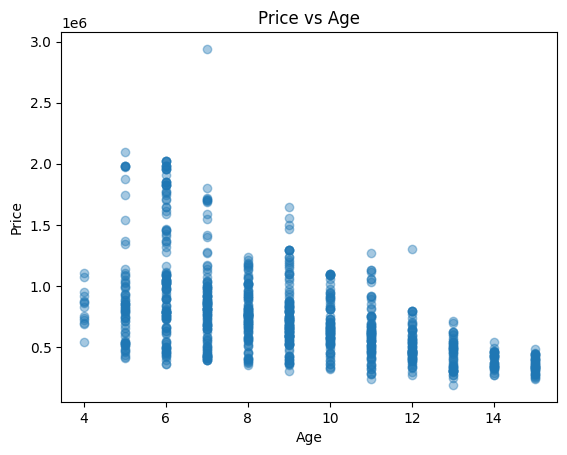

In [26]:
import matplotlib.pyplot as plt

plt.scatter(df["Age"], df["Price"], alpha=0.4)
plt.title("Price vs Age")
plt.xlabel("Age")
plt.ylabel("Price")
plt.show()

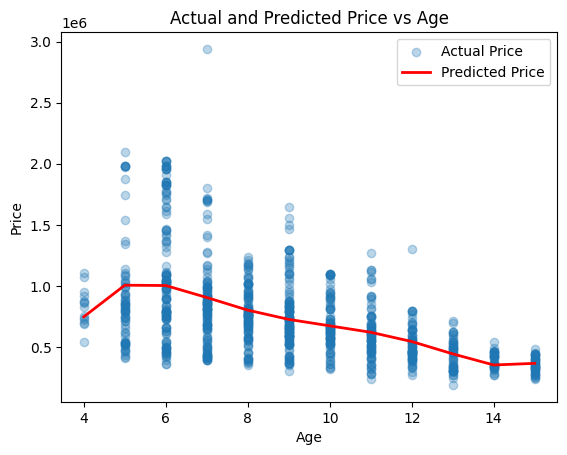

In [27]:
plot_df = df.sort_values("Age")

plt.scatter(df["Age"], df["Price"], alpha=0.3, label="Actual Price")
plt.plot(plot_df["Age"], plot_df["predicted_price"],
         color="red", linewidth=2, label="Predicted Price")

plt.title("Actual and Predicted Price vs Age")
plt.xlabel("Age")
plt.ylabel("Price")
plt.legend()
plt.show()

The scatter plot shows that car prices generally decrease as age increases. The model-predicted curve follows this downward pattern, indicating that the model captures the main relationship between age and price. While the predicted values do not perfectly match every data point, the curve tracks the overall trend in the data, so the model fits the patterns reasonably well.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [29]:
df = pd.read_csv("heart_hw.csv")   # or "./data/heart_hw.csv"
df.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


In [30]:
df.columns
df["transplant"].value_counts()

,count
transplant,
treatment,69
control,34


In [31]:
survival_rates = df.groupby("transplant")["y"].mean()
print(survival_rates)

transplant
control      0.117647
treatment    0.347826
Name: y, dtype: float64


In [32]:
a = survival_rates["control"]
b = survival_rates["treatment"]
ate = b - a

print("Control survival rate:", a)
print("Treatment survival rate:", b)
print("ATE (treatment - control):", ate)

Control survival rate: 0.11764705882352941
Treatment survival rate: 0.34782608695652173
ATE (treatment - control): 0.23017902813299232


The survival rate in the control group is about 0.118, while the survival rate in the treatment group is about 0.348. The average treatment effect (ATE) is approximately 0.230, meaning that receiving a heart transplant is associated with about a 23-percentage-point increase in three-year survival compared to not receiving a transplant.

In [33]:
transplant_dummies = pd.get_dummies(df["transplant"], drop_first=True)
X = transplant_dummies
y = df["y"]

model1 = LinearRegression()
model1.fit(X, y)

print("Intercept:", model1.intercept_)
for name, coef in zip(X.columns, model1.coef_):
    print(name, coef)

Intercept: 0.1176470588235293
treatment 0.23017902813299249


The control group survival rate is about 0.118, and the treatment group survival rate is about 0.348. The ATE is about 0.230, meaning transplant patients are about 23 percentage points more likely to survive three years. In the regression, the intercept equals the control survival rate, and the treatment coefficient equals the difference between treatment and control. These match the values calculated earlier.

In [34]:
X2 = pd.concat([transplant_dummies, df[["age"]]], axis=1)
y = df["y"]

model2 = LinearRegression()
model2.fit(X2, y)

print("Intercept:", model2.intercept_)
for name, coef in zip(X2.columns, model2.coef_):
    print(name, coef)

Intercept: 0.7019569721740947
treatment 0.2647016865036751
age -0.013607217160218647


In [35]:
print("ATE from part 1:", ate)
print("Treatment coef controlling for age:", model2.coef_[list(X2.columns).index("treatment")])

ATE from part 1: 0.23017902813299232
Treatment coef controlling for age: 0.2647016865036751


When age is added to the model, the transplant effect increases from about 0.23 to about 0.265. This suggests that age was influencing the original comparison. Transplant patients were probably older on average, and since older patients are less likely to survive, the simple ATE understated how beneficial the transplant actually is.

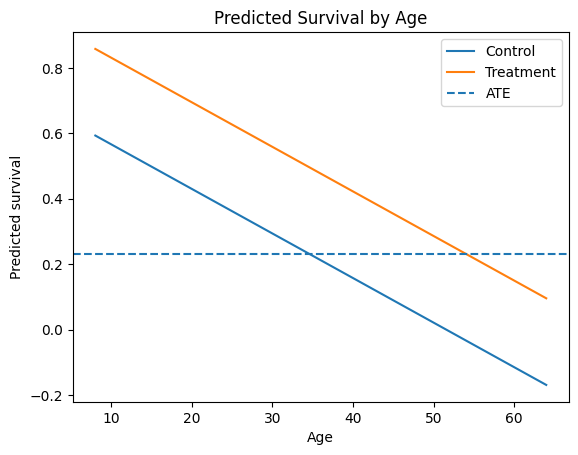

In [37]:
ages = np.linspace(df["age"].min(), df["age"].max(), 100)

pred_control = model2.predict(pd.DataFrame({
    "treatment": 0,
    "age": ages
}))

pred_treat = model2.predict(pd.DataFrame({
    "treatment": 1,
    "age": ages
}))

plt.plot(ages, pred_control, label="Control")
plt.plot(ages, pred_treat, label="Treatment")
plt.axhline(ate, linestyle="--", label="ATE")

plt.xlabel("Age")
plt.ylabel("Predicted survival")
plt.title("Predicted Survival by Age")
plt.legend()
plt.show()

In [38]:
treat_coef = model2.coef_[list(X2.columns).index("treatment")]
print("Constant treatment effect in model 2:", treat_coef)
print("ATE from part 1:", ate)

Constant treatment effect in model 2: 0.2647016865036751
ATE from part 1: 0.23017902813299232


There is no interaction in this model, therefore the transplant effect is the same at every age. If the treatment coefficient is greater ATE, then the ATE underestimates the age-adjusted effect at all ages. If treatment coefficient is less than ATE, then the ATE overestimates the age adjusted effect at all ages.

In [39]:

df["treatment"] = (df["transplant"] == "treatment").astype(int)


df["treat_age"] = df["treatment"] * df["age"]

model3 = LinearRegression().fit(
    df[["treatment", "age", "treat_age"]],
    df["y"]
)


print("Intercept:", model3.intercept_)
print("Coefficients:", model3.coef_)

Intercept: 0.35486517529945855
Coefficients: [ 0.90775139 -0.00552426 -0.01459064]


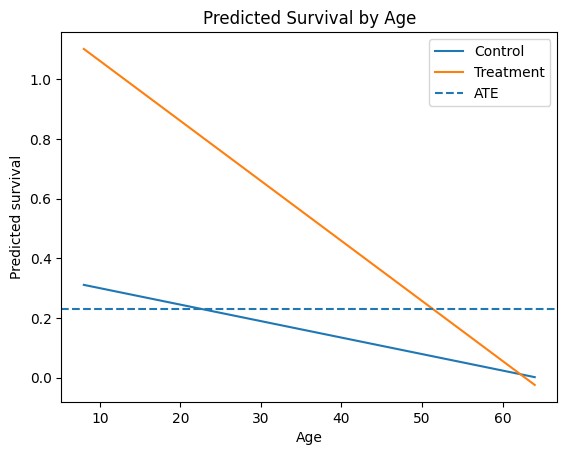

In [42]:
ages = np.linspace(df["age"].min(), df["age"].max(), 100)

pred_control = model3.predict(pd.DataFrame({
    "treatment": 0,
    "age": ages,
    "treat_age": 0
}))

pred_treat = model3.predict(pd.DataFrame({
    "treatment": 1,
    "age": ages,
    "treat_age": ages
}))

plt.plot(ages, pred_control, label="Control")
plt.plot(ages, pred_treat, label="Treatment")
plt.axhline(ate, linestyle="--", label="ATE")

plt.xlabel("Age")
plt.ylabel("Predicted survival")
plt.title("Predicted Survival by Age")
plt.legend()
plt.show()

When age and transplant are allowed to interact, the effect of transplant changes depending on age instead of staying the same for everyone. The negative interaction term shows that the transplant benefit gets smaller as patients get older. This means younger patients gain more from a transplant, while older patients gain less. The predicted survival lines for treatment and control are no longer parallel, showing that age affects the treatment impact.

In [43]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression

kf = KFold(n_splits=10, shuffle=True, random_state=42)

mse1 = -cross_val_score(LinearRegression(),
                        transplant_dummies,
                        df["y"],
                        cv=kf,
                        scoring="neg_mean_squared_error").mean()

mse2 = -cross_val_score(LinearRegression(),
                        df[["treatment", "age"]],
                        df["y"],
                        cv=kf,
                        scoring="neg_mean_squared_error").mean()

mse3 = -cross_val_score(LinearRegression(),
                        df[["treatment", "age", "treat_age"]],
                        df["y"],
                        cv=kf,
                        scoring="neg_mean_squared_error").mean()

print("Model 1:", mse1)
print("Model 2:", mse2)
print("Model 3:", mse3)

Model 1: 0.1930687841733136
Model 2: 0.1772665165855078
Model 3: 0.17512042221989654


I am curious if this model would be efficient or effective. Patients who recieve transplants may differ from those who do not in ways that affect survival. And the linear probability model may produce unrealisitic predictions outside the range of valid probabilities. Plus, if past treatment outcomes or decisions reflected missing information or incorrect information the model could reinforce unfair outcomes. Therefore, using this model to decide who gets a transplant may be unfair and incorrect therefore should at the minimum not be used on its own as the one determining factor.